# Task 3 – Dataset Analysis  
## Plant Disease Classification Project  

### Objective:
To explore and analyze the PlantVillage dataset before model training.

### Goals:
- Count total images
- Count total classes
- Analyze class distribution
- Check image resolution
- Visualize sample images

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random

## 1. Dataset Overview

The dataset is stored inside the project folder under:

In [4]:
# Path to dataset
dataset_path = './dataset'

# Initialize counters
total_images = 0
class_counts = {}

# Iterate through classes
for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_folder):
        num_images = len(os.listdir(class_folder))
        class_counts[class_name] = num_images
        total_images += num_images

# Display results
print(f"Total Classes: {len(class_counts)}")
print(f"Total Images: {total_images}")

# Sample class distribution
for k, v in list(class_counts.items())[:5]:
    print(f"{k}: {v} images")

Total Classes: 16
Total Images: 20654
Pepper__bell___Bacterial_spot: 997 images
Pepper__bell___healthy: 1478 images
PlantVillage: 15 images
Potato___Early_blight: 1000 images
Potato___healthy: 152 images


## 2. Class Distribution Visualization

We visualize how images are distributed across different classes.  
This helps detect class imbalance before training.

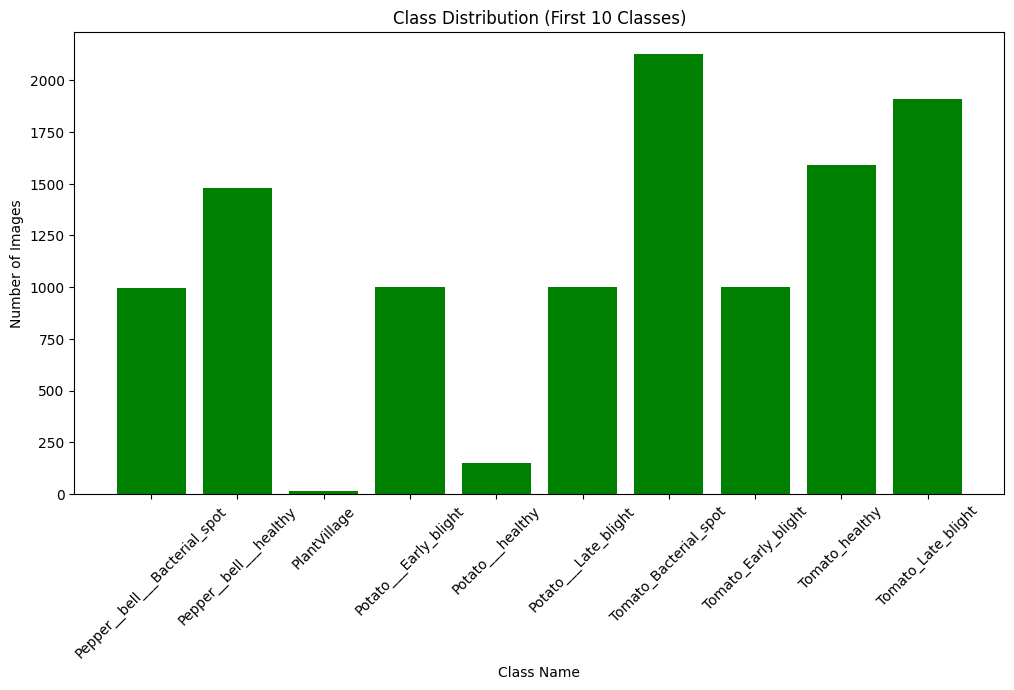

In [5]:
# Plot bar chart of first 10 classes
plt.figure(figsize=(12,6))
classes_to_plot = list(class_counts.keys())[:10]
counts_to_plot = [class_counts[c] for c in classes_to_plot]
plt.bar(classes_to_plot, counts_to_plot, color='green')
plt.xticks(rotation=45)
plt.title("Class Distribution (First 10 Classes)")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.show()

## 3. Image Resolution Analysis

We select a random image from each class and check its resolution.  
This helps determine if resizing is required before training.

In [7]:
# 3. Image Resolution Analysis (Corrected)

from PIL import UnidentifiedImageError

resolutions = []

for class_name in list(class_counts.keys())[:5]:  # first 5 classes
    class_folder = os.path.join(dataset_path, class_name)
    
    # Filter only files (ignore subfolders)
    image_files = [f for f in os.listdir(class_folder) 
                   if os.path.isfile(os.path.join(class_folder, f))]
    
    if not image_files:
        print(f"No images found in {class_name}")
        continue
    
    img_name = random.choice(image_files)
    img_path = os.path.join(class_folder, img_name)
    
    try:
        img = Image.open(img_path)
        resolutions.append(img.size)
        print(f"{class_name}: {img_name} → {img.size}")
    except (PermissionError, UnidentifiedImageError) as e:
        print(f"Could not open {img_name} in {class_name}: {e}")

# Print unique resolutions
print("\nUnique resolutions in sampled images:", set(resolutions))

Pepper__bell___Bacterial_spot: 895a07dd-367e-4e79-8730-27bec5d951e9___JR_B.Spot 3259.JPG → (256, 256)
Pepper__bell___healthy: d6e06adc-15b1-4513-97b7-7e7b3920824f___JR_HL 8258.JPG → (256, 256)
No images found in PlantVillage
Potato___Early_blight: 77c86eac-945e-4942-8eab-1269373d645a___RS_Early.B 7755.JPG → (256, 256)
Potato___healthy: 1b434c52-7be4-40c4-90d5-13220f1a3eba___RS_HL 5418.JPG → (256, 256)

Unique resolutions in sampled images: {(256, 256)}


## 4. Sample Images Visualization

We display 2 random images from different classes to visualize the dataset.

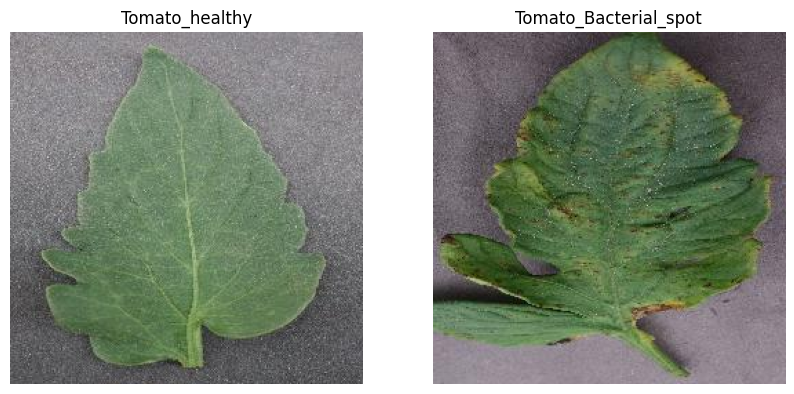

In [8]:
plt.figure(figsize=(10,5))

sample_classes = random.sample(list(class_counts.keys()), 2)
for i, class_name in enumerate(sample_classes, 1):
    class_folder = os.path.join(dataset_path, class_name)
    img_name = random.choice(os.listdir(class_folder))
    img_path = os.path.join(class_folder, img_name)
    img = Image.open(img_path)
    
    plt.subplot(1,2,i)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.show()

## 5. Conclusion

- The dataset contains multiple plant disease classes.
- Images are organized folder-wise.
- Most images have consistent resolution, but resizing may still be required.
- The dataset is ready for preprocessing and model training.

Task 3 completed successfully.